## Nelson-Siegel 
$$r(t) = \beta_0+\beta_1(\frac{1-e^{-\lambda t}}{\lambda t}) + \beta_2(\frac{1-e^{-\lambda t}}{\lambda t}-e^{-\lambda t})$$

### 1. Start with One-Day data

#### The model parameters $\beta_i$ and $t$ can be estimated using a "Least squares approach", the optimal params are set such that the sum of squared errors is minimized.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares

# year 2025
csv_path = "../data/daily-treasury-rates.csv"  
df = pd.read_csv(csv_path)

df["Date"] = pd.to_datetime(df["Date"])

# use the latest available date
row = df.sort_values("Date").iloc[-1]

# mapping：column -> time to maturity in years
TENOR_MAP = {
    "1 Mo":   1/12,
    "1.5 Mo": 1.5/12,  
    "2 Mo":   2/12,
    "3 Mo":   3/12,
    "4 Mo":   4/12,
    "6 Mo":   6/12,
    "1 Yr":   1.0,
    "2 Yr":   2.0,
    "3 Yr":   3.0,
    "5 Yr":   5.0,
    "7 Yr":   7.0,
    "10 Yr":  10.0,
    "20 Yr":  20.0,
    "30 Yr":  30.0
}

taus = []
ys = []

for col, tau in TENOR_MAP.items():
    if col in row.index:
        val = row[col]
        # handling N/A
        try:
            v = float(val)
        except (TypeError, ValueError):
            continue
        if np.isfinite(v):
            taus.append(tau)
            ys.append(v / 100.0)  # convert % to decimal

taus = np.array(taus, dtype=float)
ys = np.array(ys, dtype=float)


idx = np.argsort(taus)
taus, ys = taus[idx], ys[idx]

print("Selected date:", row["Date"].date())
print("Tenors (years):", taus)
print("Yields (decimals):", ys)

Selected date: 2025-12-31
Tenors (years): [ 0.08333333  0.16666667  0.25        0.33333333  0.5         1.
  2.          3.          5.          7.         10.         20.
 30.        ]
Yields (decimals): [0.0374 0.0367 0.0367 0.0363 0.0359 0.0348 0.0347 0.0355 0.0373 0.0394
 0.0418 0.0479 0.0484]


In [2]:
# Nelson–Siegel model 
def ns_yield(tau, beta0, beta1, beta2, lam):
    # avoid tau=0
    tau = np.asarray(tau)
    x = lam * tau
    factor1 = (1.0 - np.exp(-x)) / x
    factor2 = factor1 - np.exp(-x)
    return beta0 + beta1 * factor1 + beta2 * factor2


def ns_residuals(params, tau, y_obs):
    beta0, beta1, beta2, lam = params
    y_hat = ns_yield(tau, beta0, beta1, beta2, lam)
    return y_obs - y_hat


# initial values
y_short = ys[0]
y_long = ys[-1]
beta0_0 = y_long                  
beta1_0 = y_short - y_long        
beta2_0 = 0.0
lam_0 = 1.0

x0 = np.array([beta0_0, beta1_0, beta2_0, lam_0])


# set constraint：lam > 0
lb = np.array([-1.0, -1.0, -1.0, 1e-6])
ub = np.array([ 1.0,  1.0,  1.0, 20.0])

res_ns = least_squares(
    ns_residuals, x0, bounds=(lb, ub),
    args=(taus, ys),
    loss="linear"   # could use "huber" to increast robustness
)

beta0, beta1, beta2, lam = res_ns.x
rmse_ns = np.sqrt(np.mean(res_ns.fun**2))

In [3]:
import os
print(os.getcwd())

/Users/malik/SelfLearning/us-treasury-yield-curve-ns-nss/notebook


## NSS: Nelson-Siegel-Svensson
$$r(t) = \beta_0+\beta_1(\frac{1-e^{-\lambda t}}{\lambda t}) + \beta_2(\frac{1-e^{-\lambda t}}{\lambda t}-e^{-\lambda t})+\beta_3(\frac{1-e^{-\mu t}}{\mu t}-e^{-\mu t})$$
#### The Svensson model extends NS by a fourth factor $\beta_3$ that allows more flexibility in modelling the curve's shape.
#### The ECB provides daily estimators for all the parameters for the Euro-area.

In [3]:
def nss_yield(tau, beta0, beta1, beta2, beta3, lam, mu):
    tau = np.asarray(tau)
    x1 = lam * tau
    x2 = mu  * tau
    f1 = (1.0 - np.exp(-x1)) / x1
    f2 = f1 - np.exp(-x1)
    f3 = (1.0 - np.exp(-x2)) / x2 - np.exp(-x2)
    return beta0 + beta1 * f1 + beta2 * f2 + beta3 * f3


def nss_residuals(params, tau, y_obs):
    beta0, beta1, beta2, beta3, lam, mu = params
    y_hat = nss_yield(tau, beta0, beta1, beta2, beta3, lam, mu)
    return y_obs - y_hat


# use NS result as initial value
x0_nss = np.array([beta0, beta1, beta2, 0.0, lam, 0.3])

lb_nss = np.array([-1.0, -1.0, -1.0, -1.0, 1e-6, 1e-6])
ub_nss = np.array([ 1.0,  1.0,  1.0,  1.0, 20.0, 20.0])


res_nss = least_squares(
    nss_residuals, x0_nss, bounds=(lb_nss, ub_nss),
    args=(taus, ys),
    loss="linear"
)

rmse_nss = np.sqrt(np.mean(res_nss.fun**2))
print("\nNSS fit:")
print("beta0,beta1,beta2,beta3,lambda,mu =", res_nss.x)
print("RMSE =", rmse_nss)


NSS fit:
beta0,beta1,beta2,beta3,lambda,mu = [ 0.05267545 -0.01485045 -0.01172892 -0.03912225  1.3724518   0.42152544]
RMSE = 0.0003092193851444195


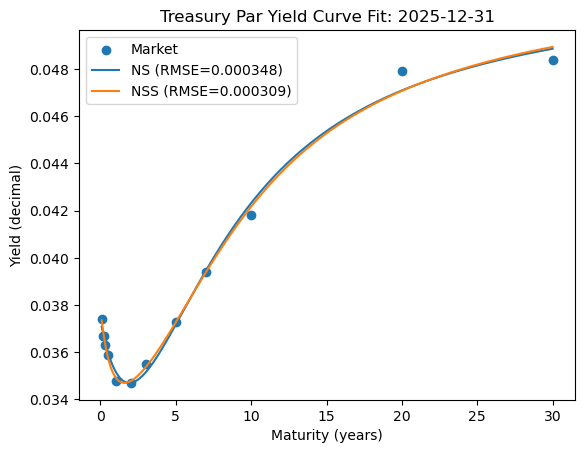

In [4]:
# plot
t_grid = np.linspace(taus.min(), taus.max(), 200)

y_fit_ns = ns_yield(t_grid, *res_ns.x)
y_fit_nss = nss_yield(t_grid, *res_nss.x)

plt.figure()
plt.scatter(taus, ys, label="Market")
plt.plot(t_grid, y_fit_ns, label=f"NS (RMSE={rmse_ns:.6f})")
plt.plot(t_grid, y_fit_nss, label=f"NSS (RMSE={rmse_nss:.6f})")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (decimal)")
plt.title(f"Treasury Par Yield Curve Fit: {row['Date'].date()}")
plt.legend()
plt.show()

# upward sloping: the longer the time to maturity, the higher the yields

In [5]:
def tenor_label(t):
    # t in years
    if t < 1:
        m = int(round(t * 12))
        return f"{m}M"
    else:
        # 1,2,3,5,7,10...
        if abs(t - int(t)) < 1e-9:
            return f"{int(t)}Y"
        return f"{t:.1f}Y"

# compute the fitted values
yhat_ns  = ns_yield(taus, *res_ns.x)
yhat_nss = nss_yield(taus, *res_nss.x)

df_curve = pd.DataFrame({
    "tenor_years": taus,
    "tenor": [tenor_label(t) for t in taus],
    "yield_market": ys,
    "yield_NS": yhat_ns,
    "yield_NSS": yhat_nss,
})

# resiudals in bp
df_curve["err_NS"]  = df_curve["yield_market"] - df_curve["yield_NS"]
df_curve["err_NSS"] = df_curve["yield_market"] - df_curve["yield_NSS"]

df_curve["err_NS_bp"]  = df_curve["err_NS"]  * 1e4
df_curve["err_NSS_bp"] = df_curve["err_NSS"] * 1e4

# yields in percentages
df_display = df_curve.copy()
for c in ["yield_market", "yield_NS", "yield_NSS"]:
    df_display[c] = (100 * df_display[c]).map(lambda x: f"{x:.3f}%")
for c in ["err_NS_bp", "err_NSS_bp"]:
    df_display[c] = df_display[c].map(lambda x: f"{x:+.2f} bp")


df_display = df_display.sort_values("tenor_years")[[
    "tenor", "tenor_years", "yield_market", "yield_NS", "yield_NSS", "err_NS_bp", "err_NSS_bp"
]]

df_display

,tenor,tenor_years,yield_market,yield_NS,yield_NSS,err_NS_bp,err_NSS_bp
0,1M,0.083333,3.740%,3.708%,3.735%,+3.22 bp,+0.50 bp
1,2M,0.166667,3.670%,3.683%,3.694%,-1.27 bp,-2.36 bp
2,3M,0.250000,3.670%,3.659%,3.658%,+1.07 bp,+1.24 bp
3,4M,0.333333,3.630%,3.638%,3.626%,-0.77 bp,+0.35 bp
4,6M,0.500000,3.590%,3.599%,3.576%,-0.93 bp,+1.38 bp
5,1Y,1.000000,3.480%,3.518%,3.493%,-3.84 bp,-1.34 bp
6,2Y,2.000000,3.470%,3.470%,3.477%,-0.01 bp,-0.73 bp
7,3Y,3.000000,3.550%,3.514%,3.536%,+3.56 bp,+1.39 bp
8,5Y,5.000000,3.730%,3.717%,3.727%,+1.28 bp,+0.34 bp
9,7Y,7.000000,3.940%,3.946%,3.939%,-0.60 bp,+0.09 bp


## 2. Rolling fit 
### for each trading day $t$, we try to fit with NS
$$\theta_t = (\beta_0(t), \beta_1(t), \beta_2(t), \lambda(t)) $$

In [6]:
df = pd.read_csv(csv_path)

df["Date"] = pd.to_datetime(df["Date"])

# we need to melt the dataframe
row = df.sort_values("Date").reset_index(drop=True)

# using the previous TENOR_MAP
tenor_cols = [c for c in TENOR_MAP.keys() if c in df.columns]

long = df[["Date"] + tenor_cols].melt(
    id_vars="Date", var_name="tenor_col", value_name="yield_pct"
)

# 转成数值并 drop NA / N/A
long["yield_pct"] = pd.to_numeric(long["yield_pct"], errors="coerce")
long = long.dropna(subset=["yield_pct"])

long["tenor_years"] = long["tenor_col"].map(TENOR_MAP)
long["yield"] = long["yield_pct"] / 100.0  # % -> decimal

# for each t, we need enough points for fitting (for example >=9)
min_points = 9
counts = long.groupby("Date")["tenor_years"].count()
valid_dates = counts[counts >= min_points].index
long = long[long["Date"].isin(valid_dates)]

In [7]:
def ns_yield(tau, beta0, beta1, beta2, lam):
    tau = np.asarray(tau, dtype=float)
    x = lam * tau
    f1 = (1.0 - np.exp(-x)) / x
    f2 = f1 - np.exp(-x)
    return beta0 + beta1 * f1 + beta2 * f2

def ns_residuals(params, tau, y_obs):
    beta0, beta1, beta2, lam = params
    return y_obs - ns_yield(tau, beta0, beta1, beta2, lam)

def fit_ns_one_day(day_df, x0=None):
    # day_df: columns [tenor_years, yield]
    tau = day_df["tenor_years"].to_numpy(float)
    y = day_df["yield"].to_numpy(float)

    idx = np.argsort(tau)
    tau, y = tau[idx], y[idx]

    if x0 is None:
        y_short, y_long = y[0], y[-1]
        beta0_0 = y_long
        beta1_0 = y_short - y_long
        beta2_0 = 0.0
        lam_0 = 1.0
        x0 = np.array([beta0_0, beta1_0, beta2_0, lam_0], dtype=float)

    # bounds：lam > 0
    lb = np.array([-1.0, -1.0, -1.0, 1e-6])
    ub = np.array([ 1.0,  1.0,  1.0, 20.0])

    res = least_squares(
        ns_residuals, x0, bounds=(lb, ub),
        args=(tau, y), loss="linear"
    )
    rmse = np.sqrt(np.mean(res.fun**2))
    return res.x, rmse, len(y)

In [8]:
# select the latest 250 trading days
dates = sorted(long["Date"].unique())
N = 250
dates = dates[-N:] if len(dates) > N else dates

rows = []
x_prev = None

for d in dates:
    day_df = long[long["Date"] == d][["tenor_years", "yield"]]
    params, rmse, npts = fit_ns_one_day(day_df, x0=x_prev)  # warm start
    x_prev = params  # use it as initial value for the next day

    rows.append({
        "Date": d,
        "beta0": params[0],
        "beta1": params[1],
        "beta2": params[2],
        "lambda": params[3],
        "rmse": rmse,
        "n_points": npts
    })

df_params = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
df_params["short_level"] = df_params["beta0"] + df_params["beta1"]
df_params["long_level"]  = df_params["beta0"]

df_params.head(), df_params.tail()

(        Date     beta0     beta1     beta2    lambda      rmse  n_points  \
 0 2025-01-02  0.049292 -0.005046 -0.015642  0.664981  0.000437        13   
 1 2025-01-03  0.049507 -0.005432 -0.014788  0.671233  0.000427        13   
 2 2025-01-06  0.049897 -0.005772 -0.015817  0.671158  0.000425        13   
 3 2025-01-07  0.050585 -0.006587 -0.015677  0.654323  0.000415        13   
 4 2025-01-08  0.050702 -0.006740 -0.016006  0.631227  0.000375        13   
 
    short_level  long_level  
 0     0.044246    0.049292  
 1     0.044075    0.049507  
 2     0.044125    0.049897  
 3     0.043998    0.050585  
 4     0.043962    0.050702  ,
           Date     beta0     beta1     beta2    lambda      rmse  n_points  \
 244 2025-12-24  0.051935 -0.014349 -0.030440  0.423387  0.000370        13   
 245 2025-12-26  0.052396 -0.015077 -0.030808  0.405492  0.000365        13   
 246 2025-12-29  0.052321 -0.014940 -0.031393  0.406968  0.000350        13   
 247 2025-12-30  0.052453 -0.015451 -0.

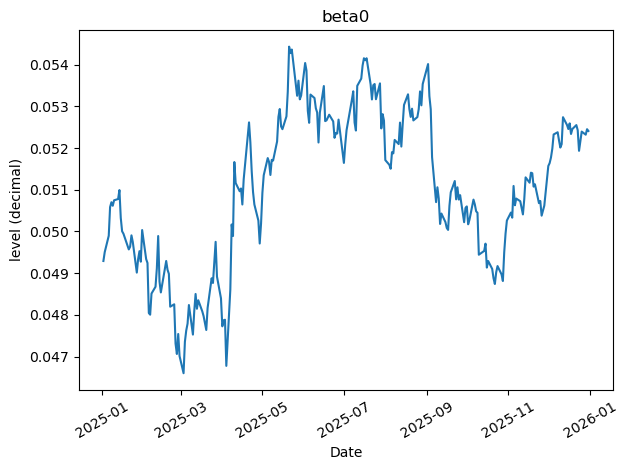

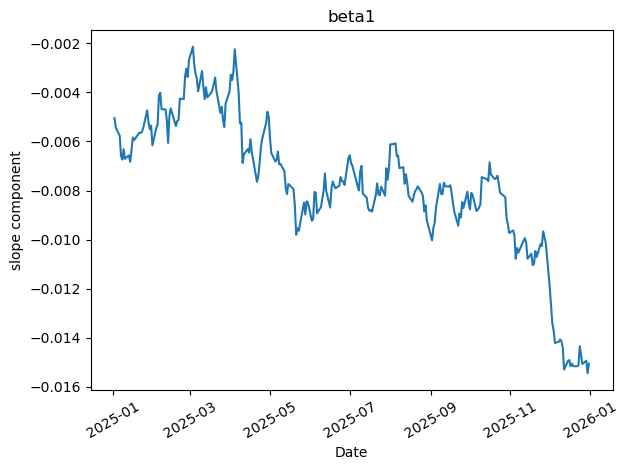

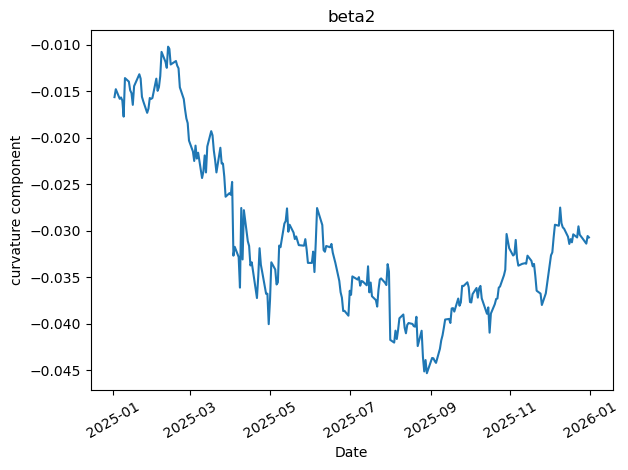

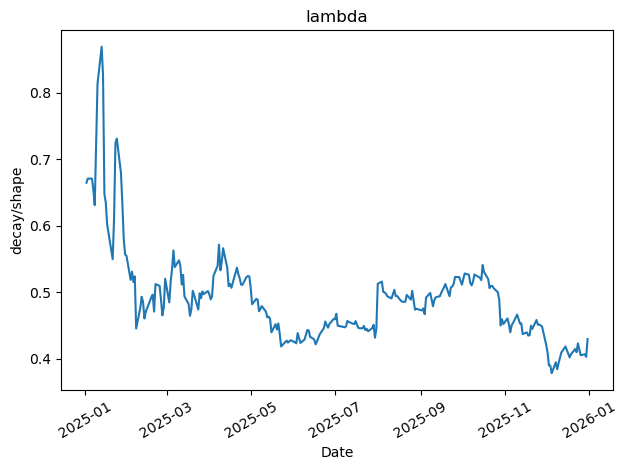

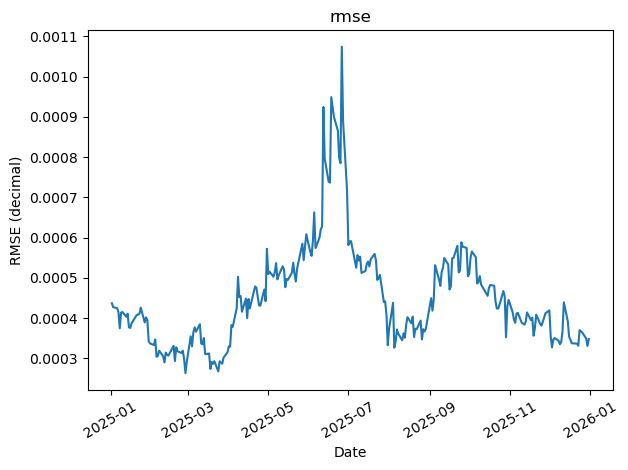

In [9]:
def plot_series(df, col, ylabel):
    plt.figure()
    plt.plot(df["Date"], df[col])
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

plot_series(df_params, "beta0", "level (decimal)")
plot_series(df_params, "beta1", "slope component")
plot_series(df_params, "beta2", "curvature component")
plot_series(df_params, "lambda", "decay/shape")
plot_series(df_params, "rmse", "RMSE (decimal)")

### $\beta_0(t)$ is highly correlated with the long term (20/30Y), we could go checking 
$$\text{corr}(\beta_0(t), y_t(30\text{Y}))$$

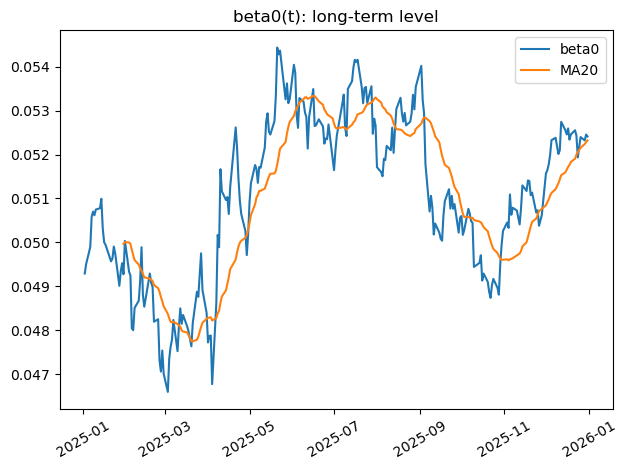

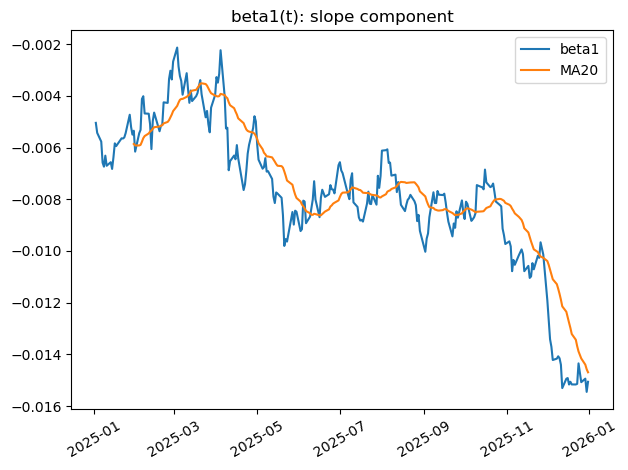

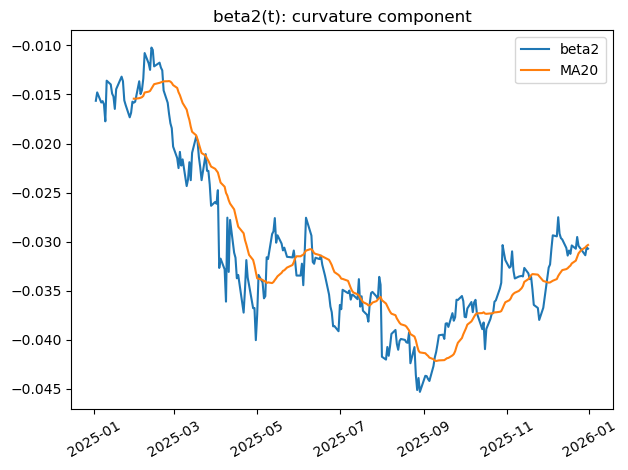

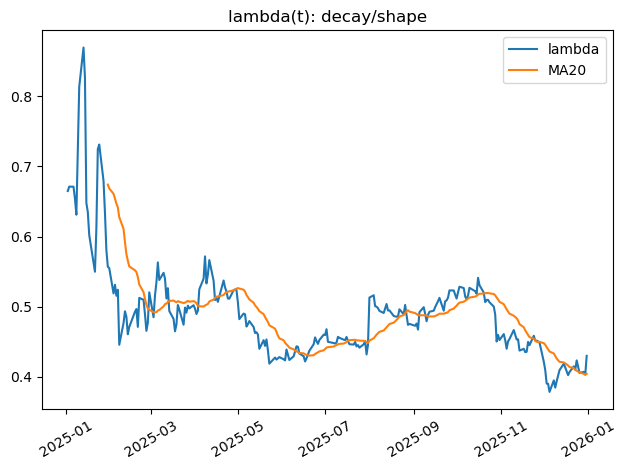

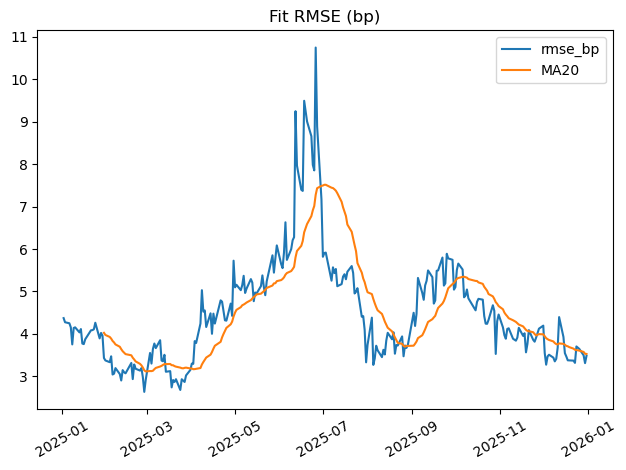

In [10]:
def plot(df, col, title=None):
    plt.figure()
    plt.plot(df["Date"], df[col], label=col)
    if col + "_ma20" in df.columns:
        plt.plot(df["Date"], df[col + "_ma20"], label="MA20")
    plt.title(title or col)
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

df_params["rmse_bp"] = df_params["rmse"]*1e4
for c in ["beta0","beta1","beta2","lambda","rmse_bp"]:
    df_params[c+"_ma20"] = df_params[c].rolling(20).mean()

plot(df_params, "beta0", "beta0(t): long-term level")
plot(df_params, "beta1", "beta1(t): slope component")
plot(df_params, "beta2", "beta2(t): curvature component")
plot(df_params, "lambda", "lambda(t): decay/shape")
plot(df_params, "rmse_bp", "Fit RMSE (bp)")

In [11]:
# validate: compare short-/long-term level with real interest rate and their correlation
# using 1M and 30Y yields
mkt_1m  = long[long["tenor_years"]==1/12].set_index("Date")["yield"].rename("y_1m")
mkt_30y = long[long["tenor_years"]==30].set_index("Date")["yield"].rename("y_30y")

tmp = df_params.set_index("Date").join([mkt_1m, mkt_30y], how="inner")
tmp["short_level"] = tmp["beta0"] + tmp["beta1"]
tmp["long_level"] = tmp["beta0"]

print(tmp[["short_level","y_1m","long_level","y_30y"]].corr())

             short_level      y_1m  long_level     y_30y
short_level     1.000000  0.941143    0.034767  0.255812
y_1m            0.941143  1.000000   -0.122742  0.158617
long_level      0.034767 -0.122742    1.000000  0.880796
y_30y           0.255812  0.158617    0.880796  1.000000


### We notice that we have high $\text{corr}(\beta_0(t), y_t(30\text{Y}))$ value

In [12]:
top = df_params.nlargest(10, "rmse")["Date"]
top.tolist()

[Timestamp('2025-06-26 00:00:00'),
 Timestamp('2025-06-18 00:00:00'),
 Timestamp('2025-06-12 00:00:00'),
 Timestamp('2025-06-20 00:00:00'),
 Timestamp('2025-06-27 00:00:00'),
 Timestamp('2025-06-23 00:00:00'),
 Timestamp('2025-06-24 00:00:00'),
 Timestamp('2025-06-13 00:00:00'),
 Timestamp('2025-06-25 00:00:00'),
 Timestamp('2025-06-16 00:00:00')]

           slope_mkt  slope_ns
slope_mkt   1.000000  0.958505
slope_ns    0.958505  1.000000


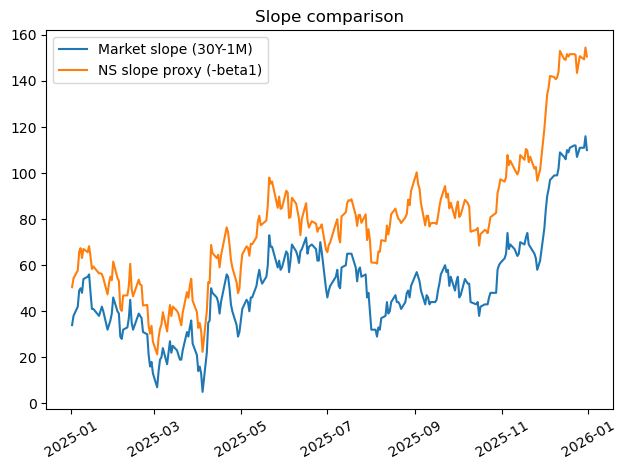

In [13]:
tmp = tmp.copy()
tmp["slope_mkt"] = (tmp["y_30y"] - tmp["y_1m"]) * 1e4      # in bp
tmp["slope_ns"]  = (-tmp["beta1"]) * 1e4                   # in bp

print(tmp[["slope_mkt","slope_ns"]].corr())

plt.figure()
plt.plot(tmp.index, tmp["slope_mkt"], label="Market slope (30Y-1M)")
plt.plot(tmp.index, tmp["slope_ns"], label="NS slope proxy (-beta1)")
plt.title("Slope comparison")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

      tenor_years   yield  yield_ns     err_bp
128      0.083333  0.0411  0.044161 -30.606153
377      0.166667  0.0449  0.043630  12.702453
626      0.250000  0.0439  0.043128   7.715775
875      0.333333  0.0436  0.042655   9.446459
1124     0.500000  0.0426  0.041789   8.108002
1373     1.000000  0.0396  0.039752  -1.522855
1622     2.000000  0.0370  0.037569  -5.688224
1871     3.000000  0.0368  0.036980  -1.802200
2120     5.000000  0.0379  0.037997  -0.969994
2369     7.000000  0.0400  0.039900   0.995404
2618    10.000000  0.0426  0.042559   0.408343
2867    20.000000  0.0481  0.047180   9.204177
3116    30.000000  0.0481  0.048899  -7.991183


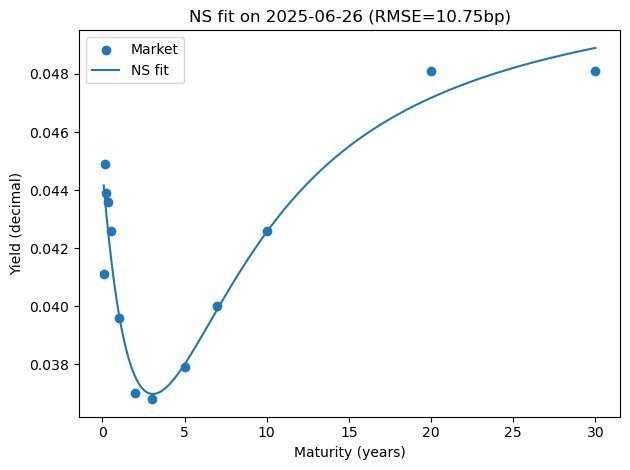

      tenor_years   yield  yield_ns     err_bp
133      0.083333  0.0420  0.044604 -26.040761
382      0.166667  0.0458  0.044200  16.002164
631      0.250000  0.0442  0.043818   3.824210
880      0.333333  0.0441  0.043457   6.434480
1129     0.500000  0.0433  0.042795   5.054373
1378     1.000000  0.0410  0.041232  -2.323916
1627     2.000000  0.0394  0.039550  -1.501023
1876     3.000000  0.0389  0.039105  -2.054511
2125     5.000000  0.0398  0.039969  -1.690660
2374     7.000000  0.0417  0.041579   1.214105
2623    10.000000  0.0438  0.043872  -0.719417
2872    20.000000  0.0489  0.047982   9.181177
3121    30.000000  0.0488  0.049538  -7.380214


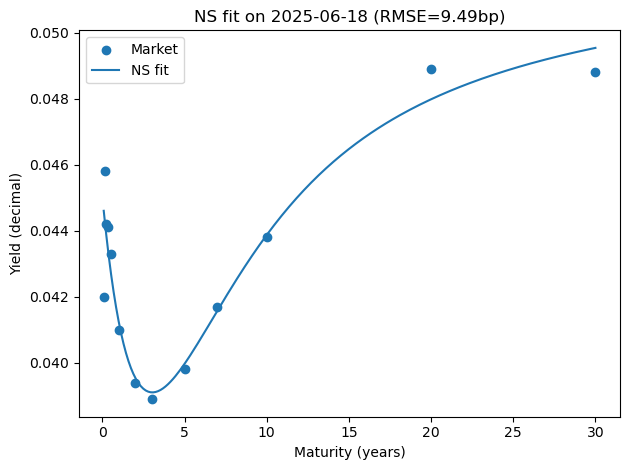

      tenor_years   yield  yield_ns     err_bp
137      0.083333  0.0418  0.044383 -25.829065
386      0.166667  0.0449  0.043960   9.398490
635      0.250000  0.0446  0.043561  10.387995
884      0.333333  0.0440  0.043185   8.149610
1133     0.500000  0.0429  0.042497   4.027817
1382     1.000000  0.0406  0.040887  -2.867948
1631     2.000000  0.0390  0.039192  -1.920026
1880     3.000000  0.0385  0.038785  -2.851835
2129     5.000000  0.0397  0.039740  -0.395054
2378     7.000000  0.0415  0.041397   1.034558
2627    10.000000  0.0436  0.043688  -0.884753
2876    20.000000  0.0486  0.047670   9.297421
3125    30.000000  0.0484  0.049155  -7.547184


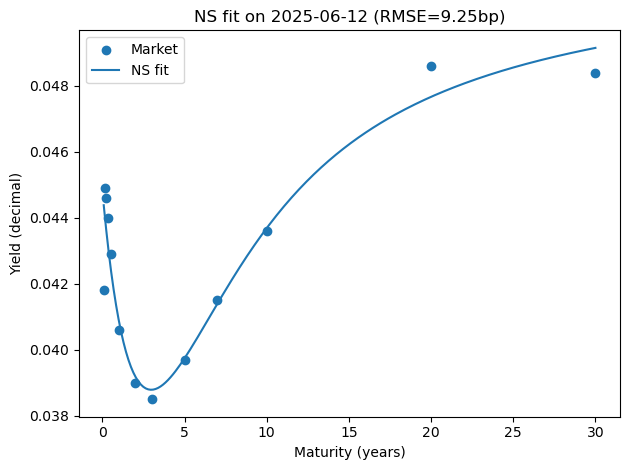

      tenor_years   yield  yield_ns     err_bp
132      0.083333  0.0420  0.044439 -24.385318
381      0.166667  0.0455  0.044011  14.890689
630      0.250000  0.0439  0.043607   2.927069
879      0.333333  0.0440  0.043227   7.733945
1128     0.500000  0.0429  0.042530   3.697712
1377     1.000000  0.0407  0.040898  -1.982344
1626     2.000000  0.0390  0.039179  -1.785871
1875     3.000000  0.0386  0.038768  -1.684285
2124     5.000000  0.0396  0.039760  -1.600512
2373     7.000000  0.0416  0.041483   1.174181
2622    10.000000  0.0438  0.043878  -0.782208
2871    20.000000  0.0490  0.048074   9.255808
3120    30.000000  0.0489  0.049646  -7.458773


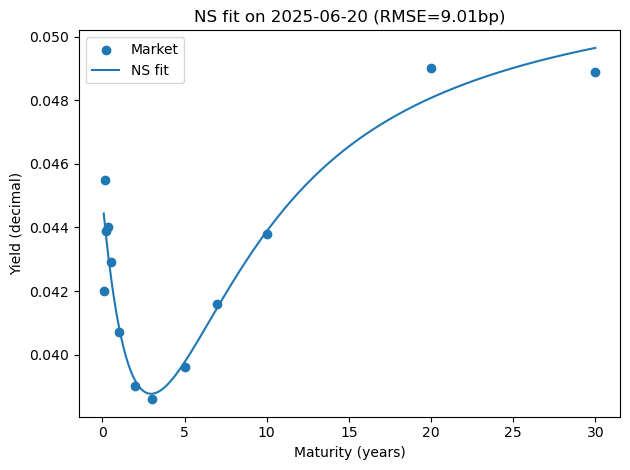

      tenor_years   yield  yield_ns     err_bp
127      0.083333  0.0419  0.044344 -24.444692
376      0.166667  0.0449  0.043811  10.893832
625      0.250000  0.0439  0.043307   5.930916
874      0.333333  0.0436  0.042832   7.679635
1123     0.500000  0.0426  0.041964   6.361674
1372     1.000000  0.0397  0.039931  -2.307187
1621     2.000000  0.0373  0.037781  -4.809066
1870     3.000000  0.0372  0.037237  -0.372827
2119     5.000000  0.0383  0.038331  -0.308243
2368     7.000000  0.0403  0.040278   0.220586
2617    10.000000  0.0429  0.042959  -0.585141
2866    20.000000  0.0485  0.047561   9.390089
3115    30.000000  0.0485  0.049265  -7.649566


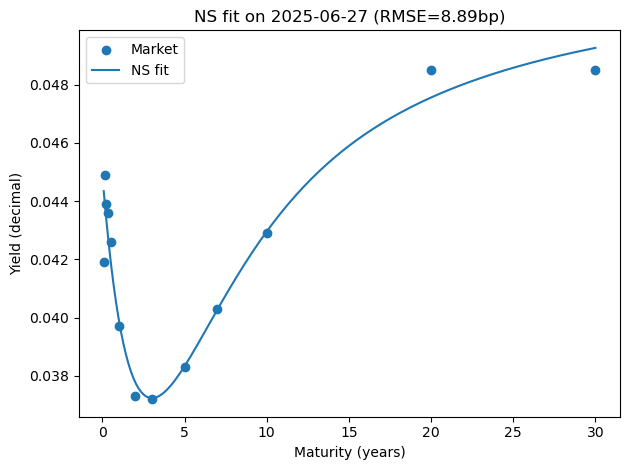

In [14]:
top_dates = df_params.nlargest(5, "rmse")["Date"].tolist()
top_dates

def curve_table_and_plot(date):
    day = long[long["Date"]==date][["tenor_years","yield"]].copy()
    day = day.sort_values("tenor_years")

    p = df_params.set_index("Date").loc[date, ["beta0","beta1","beta2","lambda"]].to_numpy(float)
    yhat = ns_yield(day["tenor_years"].to_numpy(), *p)

    out = day.copy()
    out["yield_ns"] = yhat
    out["err_bp"] = (out["yield"] - out["yield_ns"]) * 1e4
    print(out)

    # plot
    t_grid = np.linspace(out["tenor_years"].min(), out["tenor_years"].max(), 200)
    y_grid = ns_yield(t_grid, *p)

    plt.figure()
    plt.scatter(out["tenor_years"], out["yield"], label="Market")
    plt.plot(t_grid, y_grid, label="NS fit")
    plt.title(f"NS fit on {pd.to_datetime(date).date()} (RMSE={df_params.set_index('Date').loc[date,'rmse']*1e4:.2f}bp)")
    plt.xlabel("Maturity (years)")
    plt.ylabel("Yield (decimal)")
    plt.legend()
    plt.tight_layout()
    plt.show()

for d in top_dates:
    curve_table_and_plot(d)

### Now we move to fitting for NSS

In [15]:
def fit_nss_one_day(day_df, x0=None):
    tau = day_df["tenor_years"].to_numpy(float)
    y   = day_df["yield"].to_numpy(float)

    idx = np.argsort(tau)
    tau, y = tau[idx], y[idx]

    if x0 is None:
        y_short, y_long = y[0], y[-1]
        beta0_0 = y_long
        beta1_0 = y_short - y_long
        beta2_0 = 0.0
        beta3_0 = 0.0
        lam_0 = 1.0
        mu_0  = 0.3
        x0 = np.array([beta0_0, beta1_0, beta2_0, beta3_0, lam_0, mu_0], dtype=float)

    lb = np.array([-1.0, -1.0, -1.0, -1.0, 1e-4, 1e-4])
    ub = np.array([ 1.0,  1.0,  1.0,  1.0,  10.0,  10.0])

    res = least_squares(
        nss_residuals, x0, bounds=(lb, ub),
        args=(tau, y), loss="linear"
    )
    rmse = np.sqrt(np.mean(res.fun**2))
    return res.x, rmse, len(y)

#### Running both NS and NSS and compare the result

In [16]:
dates = sorted(long["Date"].unique())
N = 250
dates = dates[-N:] if len(dates) > N else dates

rows_ns = []
rows_nss = []

x_prev_ns = None
x_prev_nss = None

for d in dates:
    day_df = long[long["Date"] == d][["tenor_years", "yield"]]
    
    # ----- NS -----
    try:
        p_ns, rmse_ns, npts = fit_ns_one_day(day_df, x0=x_prev_ns)
        x_prev_ns = p_ns
        ok_ns = True
    except Exception:
        p_ns = [np.nan]*4
        rmse_ns = np.nan
        npts = len(day_df)
        ok_ns = False

    rows_ns.append({
        "Date": d, "beta0": p_ns[0], "beta1": p_ns[1], "beta2": p_ns[2], "lambda": p_ns[3],
        "rmse": rmse_ns, "n_points": npts, "ok": ok_ns
    })

    # ----- NSS -----
    if x_prev_nss is None and ok_ns:
        # use NS as starting point, beta3=0, mu=0.3
        x0_nss = np.array([p_ns[0], p_ns[1], p_ns[2], 0.0, max(p_ns[3], 0.3), 0.3], dtype=float)
    else:
        x0_nss = x_prev_nss

    try:
        p_nss, rmse_nss, npts2 = fit_nss_one_day(day_df, x0=x0_nss)
        x_prev_nss = p_nss
        ok_nss = True
    except Exception:
        if ok_ns:
            x0_nss_fb = np.array([p_ns[0], p_ns[1], p_ns[2], 0.0, max(p_ns[3], 0.3), 0.3], dtype=float)
            try:
                p_nss, rmse_nss, npts2 = fit_nss_one_day(day_df, x0=x0_nss_fb)
                x_prev_nss = p_nss
                ok_nss = True
            except Exception:
                p_nss = [np.nan]*6
                rmse_nss = np.nan
                npts2 = len(day_df)
                ok_nss = False
        else:
            p_nss = [np.nan]*6
            rmse_nss = np.nan
            npts2 = len(day_df)
            ok_nss = False

    rows_nss.append({
        "Date": d,
        "beta0": p_nss[0], "beta1": p_nss[1], "beta2": p_nss[2], "beta3": p_nss[3],
        "lambda": p_nss[4], "mu": p_nss[5],
        "rmse": rmse_nss, "n_points": npts2, "ok": ok_nss
    })

df_ns  = pd.DataFrame(rows_ns).sort_values("Date").reset_index(drop=True)
df_nss = pd.DataFrame(rows_nss).sort_values("Date").reset_index(drop=True)

# merge for comparison
df_compare = df_ns[["Date","rmse","ok"]].rename(columns={"rmse":"rmse_ns","ok":"ok_ns"}) \
    .merge(df_nss[["Date","rmse","ok"]].rename(columns={"rmse":"rmse_nss","ok":"ok_nss"}), on="Date", how="inner")

df_compare["rmse_ns_bp"]  = df_compare["rmse_ns"]  * 1e4
df_compare["rmse_nss_bp"] = df_compare["rmse_nss"] * 1e4
df_compare["rmse_gain_bp"] = df_compare["rmse_ns_bp"] - df_compare["rmse_nss_bp"]  # >0 means NSS performs better

df_compare.head()

,Date,rmse_ns,ok_ns,rmse_nss,ok_nss,rmse_ns_bp,rmse_nss_bp,rmse_gain_bp
0,2025-01-02,0.000437,True,0.000313,True,4.372254,3.131059,1.241195
1,2025-01-03,0.000427,True,0.000294,True,4.274710,2.935041,1.339669
2,2025-01-06,0.000425,True,0.000306,True,4.250449,3.057300,1.193149
3,2025-01-07,0.000415,True,0.000307,True,4.154833,3.074678,1.080156
4,2025-01-08,0.000375,True,0.000304,True,3.752730,3.039674,0.713056


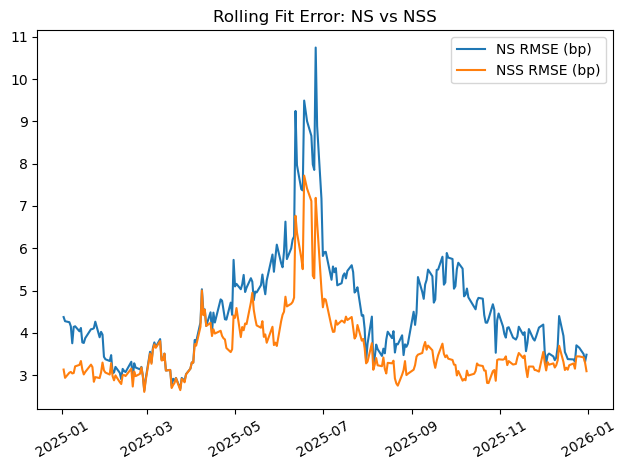

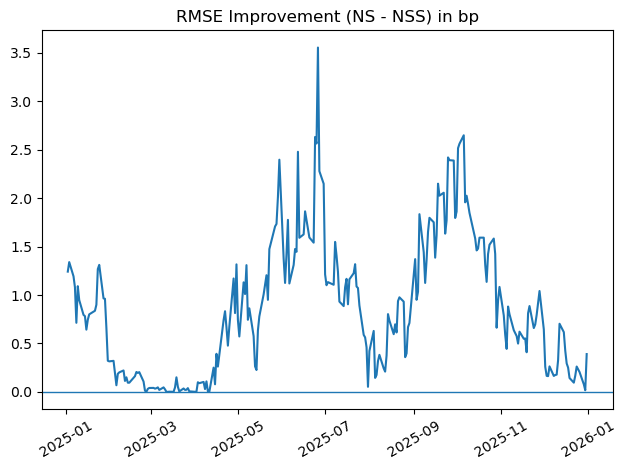

Average RMSE (bp):
NS : 4.4765134247585
NSS: 3.620503276296013
Average improvement (bp): 0.8560101484624877
Share of days where NSS improves: 1.0


In [17]:
plt.figure()
plt.plot(df_compare["Date"], df_compare["rmse_ns_bp"], label="NS RMSE (bp)")
plt.plot(df_compare["Date"], df_compare["rmse_nss_bp"], label="NSS RMSE (bp)")
plt.title("Rolling Fit Error: NS vs NSS")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df_compare["Date"], df_compare["rmse_gain_bp"])
plt.axhline(0, linewidth=1)
plt.title("RMSE Improvement (NS - NSS) in bp")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Average RMSE (bp):")
print("NS :", df_compare["rmse_ns_bp"].mean())
print("NSS:", df_compare["rmse_nss_bp"].mean())
print("Average improvement (bp):", df_compare["rmse_gain_bp"].mean())
print("Share of days where NSS improves:", (df_compare["rmse_gain_bp"] > 0).mean())

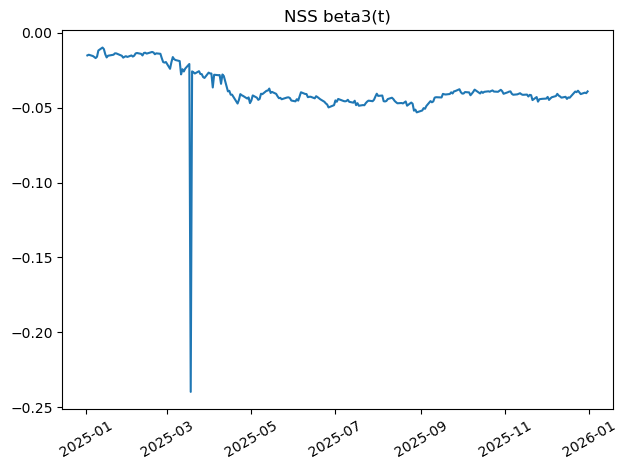

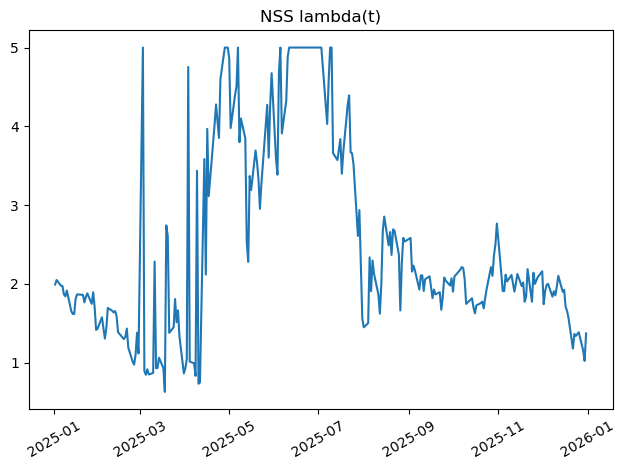

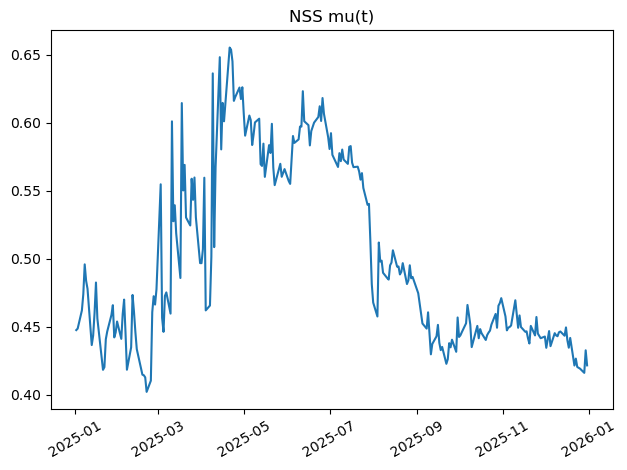

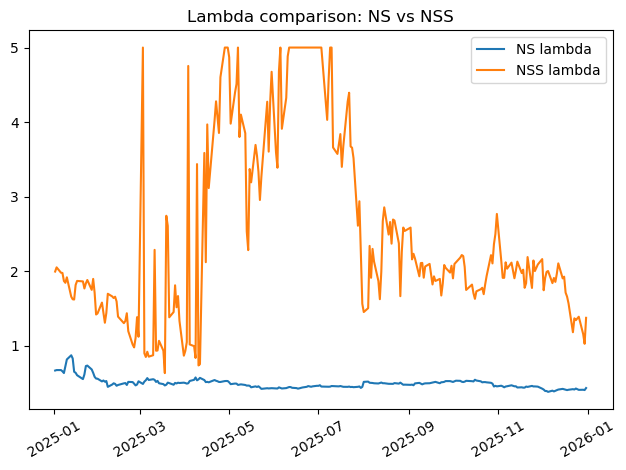

In [18]:
def plot_param(df, col, title=None):
    plt.figure()
    plt.plot(df["Date"], df[col])
    plt.title(title or col)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# NSS params
plot_param(df_nss, "beta3", "NSS beta3(t)")
plot_param(df_nss, "lambda", "NSS lambda(t)")
plot_param(df_nss, "mu", "NSS mu(t)")

# compare NS and NSS's lambda
plt.figure()
plt.plot(df_ns["Date"], df_ns["lambda"], label="NS lambda")
plt.plot(df_nss["Date"], df_nss["lambda"], label="NSS lambda")
plt.title("Lambda comparison: NS vs NSS")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
df_compare[["rmse_ns_bp","rmse_nss_bp","rmse_gain_bp"]].describe()

,rmse_ns_bp,rmse_nss_bp,rmse_gain_bp
count,249.000000,249.000000,249.000000
mean,4.476513,3.620503,0.856010
std,1.272938,0.829801,0.698363
min,2.634518,2.603268,0.000015
25%,3.550578,3.107435,0.209100
50%,4.187272,3.332893,0.744176
75%,5.126257,3.923966,1.314234
max,10.746000,7.718004,3.554391


In [21]:
# check whether we need to broaden bounds
upper_lam = 10.0
upper_mu  = 5.0

hit_lam = (df_nss["lambda"] >= upper_lam - 1e-6).mean()
hit_mu  = (df_nss["mu"]     >= upper_mu  - 1e-6).mean()

print("Lambda hits upper bound ratio:", hit_lam)
print("Mu hits upper bound ratio:", hit_mu)

# we prefer 10 over 5 for upper_lam, the latter has about 8% ratio

Lambda hits upper bound ratio: 0.0
Mu hits upper bound ratio: 0.0


### Now tryto predict the future curve based on today's parameters
#### for each $t$:
$$ \text{use } \theta_t \text{ to generate } t+1 \text{fitted yields}: $$
$$\hat{y}_{t+1}(\tau_{i+1};\theta_t)$$
and compute
$$\text{RMSE}^{OOS}(t+1)=\sqrt{\frac{1}{n}\sum_i (y_{t+1,i}-\hat{y}_{t+1,i})^2}$$

In [22]:
def oos_rmse_for_date(model, date, params, long_df):
    day = long_df[long_df["Date"]==date][["tenor_years","yield"]].copy().sort_values("tenor_years")
    tau = day["tenor_years"].to_numpy(float)
    y   = day["yield"].to_numpy(float)

    if model == "NS":
        yhat = ns_yield(tau, *params)  # params: [b0,b1,b2,lam]
    else:
        yhat = nss_yield(tau, *params) # params: [b0,b1,b2,b3,lam,mu]

    rmse = np.sqrt(np.mean((y - yhat)**2))
    return rmse

# use t's parameter to predict t + 1
dates = df_ns["Date"].tolist()  # or with  df_nss
oos_rows = []

for i in range(len(dates)-1):
    d_train = dates[i]
    d_test  = dates[i+1]

    p_ns  = df_ns.set_index("Date").loc[d_train, ["beta0","beta1","beta2","lambda"]].to_numpy(float)
    p_nss = df_nss.set_index("Date").loc[d_train, ["beta0","beta1","beta2","beta3","lambda","mu"]].to_numpy(float)

    rmse_oos_ns  = oos_rmse_for_date("NS",  d_test, p_ns,  long)
    rmse_oos_nss = oos_rmse_for_date("NSS", d_test, p_nss, long)

    oos_rows.append({
        "Date": d_test,
        "rmse_oos_ns_bp":  rmse_oos_ns  * 1e4,
        "rmse_oos_nss_bp": rmse_oos_nss * 1e4
    })

df_oos = pd.DataFrame(oos_rows).sort_values("Date").reset_index(drop=True)
df_oos["gain_oos_bp"] = df_oos["rmse_oos_ns_bp"] - df_oos["rmse_oos_nss_bp"]

df_oos.describe()

,Date,rmse_oos_ns_bp,rmse_oos_nss_bp,gain_oos_bp
count,248,248.000000,248.000000,248.000000
mean,2025-07-02 15:52:15.483870976,5.830517,5.161625,0.668892
min,2025-01-03 00:00:00,3.223051,3.011802,-0.277786
25%,2025-04-02 18:00:00,4.453041,3.860457,0.145152
50%,2025-07-02 12:00:00,5.407437,4.496750,0.555605
75%,2025-09-30 06:00:00,6.623026,5.828404,1.037580
max,2025-12-31 00:00:00,15.514359,15.571396,3.070661
std,NaN,1.890004,1.859288,0.620230


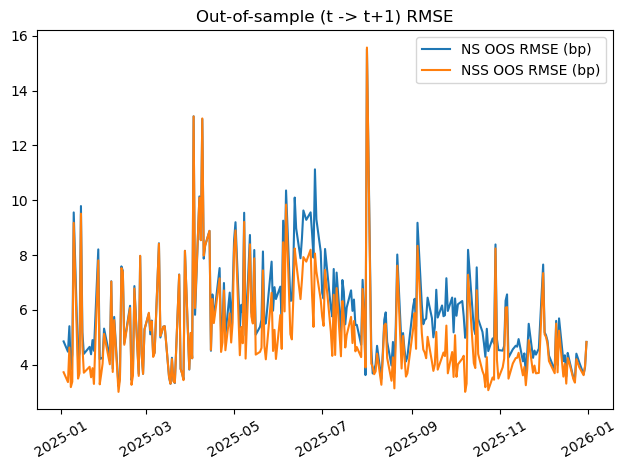

Share NSS improves OOS: 0.9112903225806451
       rmse_oos_ns_bp  rmse_oos_nss_bp  gain_oos_bp
count      248.000000       248.000000   248.000000
mean         5.830517         5.161625     0.668892
std          1.890004         1.859288     0.620230
min          3.223051         3.011802    -0.277786
25%          4.453041         3.860457     0.145152
50%          5.407437         4.496750     0.555605
75%          6.623026         5.828404     1.037580
max         15.514359        15.571396     3.070661


In [23]:
plt.figure()
plt.plot(df_oos["Date"], df_oos["rmse_oos_ns_bp"], label="NS OOS RMSE (bp)")
plt.plot(df_oos["Date"], df_oos["rmse_oos_nss_bp"], label="NSS OOS RMSE (bp)")
plt.title("Out-of-sample (t -> t+1) RMSE")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print("Share NSS improves OOS:", (df_oos["gain_oos_bp"] > 0).mean())
print(df_oos[["rmse_oos_ns_bp","rmse_oos_nss_bp","gain_oos_bp"]].describe())

In [24]:
# find the worst dates
df_oos.nsmallest(5, "gain_oos_bp")[["Date","rmse_oos_ns_bp","rmse_oos_nss_bp","gain_oos_bp"]]

,Date,rmse_oos_ns_bp,rmse_oos_nss_bp,gain_oos_bp
143,2025-07-31,3.624343,3.902129,-0.277786
63,2025-04-04,5.823360,6.069970,-0.246610
146,2025-08-05,3.683492,3.910177,-0.226684
40,2025-03-04,5.111323,5.257835,-0.146513
67,2025-04-10,7.872082,7.984814,-0.112732


In [25]:
tmp = df_oos.merge(
    df_params[["Date","beta1"]], on="Date", how="left"
)
tmp["slope_proxy_bp"] = (-tmp["beta1"]) * 1e4

tmp["bucket"] = pd.qcut(tmp["slope_proxy_bp"], 3, labels=["low","mid","high"])
tmp.groupby("bucket")["gain_oos_bp"].agg(["mean","median","count"])

/var/folders/zt/lbh39vcn4ksbgkj7px6j4qxm0000gn/T/ipykernel_1523/2546732531.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("bucket")["gain_oos_bp"].agg(["mean","median","count"])


,mean,median,count
bucket,,,
low,0.246881,0.071209,83
mid,0.989717,0.929597,82
high,0.773944,0.598461,83


In [26]:
def diagnose_oos_by_tenor(test_date, long, df_ns, df_nss):
   
    test_date = pd.to_datetime(test_date)

    dates = sorted(pd.to_datetime(df_ns["Date"]).unique())
    if test_date not in dates:
        raise ValueError(f"{test_date.date()} is not in the df_ns dates (probably not trading day) ")

    idx = dates.index(test_date)
    if idx == 0:
        raise ValueError("No data for first trading day, diagnose for t->t+1 OOS cannot be done")

    train_date = dates[idx - 1]

    # take the market data from test date
    day = long[long["Date"] == test_date].copy()
    if day.empty:
        raise ValueError(f"long cannot find data for {test_date.date()} ")

    cols_needed = ["tenor_years", "yield"]
    if "tenor" in day.columns:
        cols_needed = ["tenor", "tenor_years", "yield"]

    day = day[cols_needed].sort_values("tenor_years").reset_index(drop=True)

    tau = day["tenor_years"].to_numpy(float)
    y_mkt = day["yield"].to_numpy(float)

    p_ns = (
        df_ns.loc[pd.to_datetime(df_ns["Date"]) == train_date, ["beta0","beta1","beta2","lambda"]]
        .iloc[0].to_numpy(float)
    )
    p_nss = (
        df_nss.loc[pd.to_datetime(df_nss["Date"]) == train_date, ["beta0","beta1","beta2","beta3","lambda","mu"]]
        .iloc[0].to_numpy(float)
    )
    
    y_ns = ns_yield(tau, *p_ns)
    y_nss = nss_yield(tau, *p_nss)

    out = day.copy()
    if "tenor" not in out.columns:
        out["tenor"] = out["tenor_years"].astype(str)

    out["yield_mkt"] = y_mkt
    out["yield_pred_ns"] = y_ns
    out["yield_pred_nss"] = y_nss

    # error (bp)
    out["err_ns_bp"] = (out["yield_mkt"] - out["yield_pred_ns"]) * 1e4
    out["err_nss_bp"] = (out["yield_mkt"] - out["yield_pred_nss"]) * 1e4

    # absolute error (bp)
    out["abs_err_ns_bp"] = out["err_ns_bp"].abs()
    out["abs_err_nss_bp"] = out["err_nss_bp"].abs()

    # >0 means NSS is better
    out["gain_by_tenor_bp"] = out["abs_err_ns_bp"] - out["abs_err_nss_bp"]

    # mark the better one
    out["winner"] = np.where(out["gain_by_tenor_bp"] > 0, "NSS", "NS")

    rmse_ns_bp = np.sqrt(np.mean(((y_mkt - y_ns) * 1e4)**2))
    rmse_nss_bp = np.sqrt(np.mean(((y_mkt - y_nss) * 1e4)**2))
    
    meta = {
        "train_date": train_date,
        "test_date": test_date,
        "rmse_ns_bp": rmse_ns_bp,
        "rmse_nss_bp": rmse_nss_bp,
        "gain_oos_bp": rmse_ns_bp - rmse_nss_bp
    }

    return out, meta

In [27]:
# plug in the date like 2025-07-31
diag, meta = diagnose_oos_by_tenor("2025-07-31", long, df_ns, df_nss)

print(meta)
diag[[
    "tenor", "tenor_years",
    "yield_mkt", "yield_pred_ns", "yield_pred_nss",
    "err_ns_bp", "err_nss_bp",
    "abs_err_ns_bp", "abs_err_nss_bp",
    "gain_by_tenor_bp", "winner"
]]

{'train_date': Timestamp('2025-07-30 00:00:00'), 'test_date': Timestamp('2025-07-31 00:00:00'), 'rmse_ns_bp': 3.6243426937679395, 'rmse_nss_bp': 3.9021287003858145, 'gain_oos_bp': -0.277786006617875}


,tenor,tenor_years,yield_mkt,yield_pred_ns,yield_pred_nss,err_ns_bp,err_nss_bp,abs_err_ns_bp,abs_err_nss_bp,gain_by_tenor_bp,winner
0,0.08333333333333333,0.083333,0.0449,0.044797,0.044456,1.025913,4.436248,1.025913,4.436248,-3.410335,NS
1,0.16666666666666666,0.166667,0.0446,0.044366,0.044228,2.337601,3.720406,2.337601,3.720406,-1.382805,NS
2,0.25,0.250000,0.0441,0.043959,0.043977,1.412676,1.226829,1.412676,1.226829,0.185846,NSS
3,0.3333333333333333,0.333333,0.0440,0.043574,0.043711,4.260989,2.888648,4.260989,2.888648,1.372341,NSS
4,0.5,0.500000,0.0431,0.042869,0.043153,2.314855,-0.534572,2.314855,0.534572,1.780283,NSS
5,1.0,1.000000,0.0410,0.041205,0.041522,-2.052666,-5.222669,2.052666,5.222669,-3.170002,NS
6,2.0,2.000000,0.0394,0.039415,0.039353,-0.154764,0.468013,0.154764,0.468013,-0.313250,NS
7,3.0,3.000000,0.0389,0.038939,0.038678,-0.385546,2.222745,0.385546,2.222745,-1.837200,NS
8,5.0,5.000000,0.0396,0.039830,0.039676,-2.298739,-0.758070,2.298739,0.758070,1.540670,NSS
9,7.0,7.000000,0.0414,0.041496,0.041562,-0.959157,-1.620456,0.959157,1.620456,-0.661298,NS


In [28]:
diag.sort_values("gain_by_tenor_bp").reset_index(drop=True)[[
    "tenor", "tenor_years",
    "err_ns_bp", "err_nss_bp",
    "abs_err_ns_bp", "abs_err_nss_bp",
    "gain_by_tenor_bp", "winner"
]]

,tenor,tenor_years,err_ns_bp,err_nss_bp,abs_err_ns_bp,abs_err_nss_bp,gain_by_tenor_bp,winner
0,0.08333333333333333,0.083333,1.025913,4.436248,1.025913,4.436248,-3.410335,NS
1,1.0,1.000000,-2.052666,-5.222669,2.052666,5.222669,-3.170002,NS
2,10.0,10.000000,-1.577676,-3.657688,1.577676,3.657688,-2.080012,NS
3,3.0,3.000000,-0.385546,2.222745,0.385546,2.222745,-1.837200,NS
4,0.16666666666666666,0.166667,2.337601,3.720406,2.337601,3.720406,-1.382805,NS
5,7.0,7.000000,-0.959157,-1.620456,0.959157,1.620456,-0.661298,NS
6,2.0,2.000000,-0.154764,0.468013,0.154764,0.468013,-0.313250,NS
7,0.25,0.250000,1.412676,1.226829,1.412676,1.226829,0.185846,NSS
8,20.0,20.000000,8.446492,8.112450,8.446492,8.112450,0.334042,NSS
9,30.0,30.000000,-7.369977,-6.281883,7.369977,6.281883,1.088094,NSS


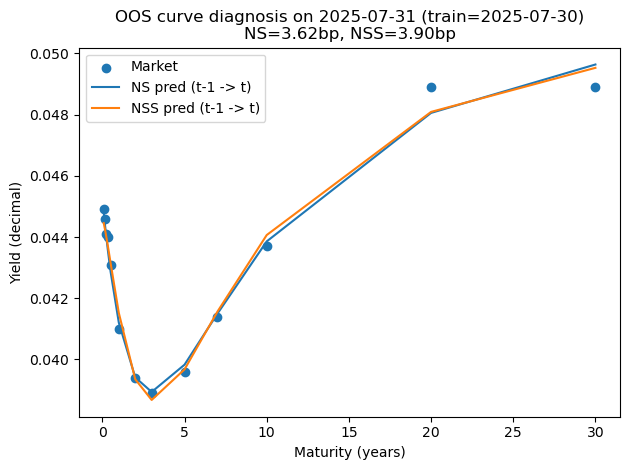

In [29]:
plt.figure()
plt.scatter(diag["tenor_years"], diag["yield_mkt"], label="Market")
plt.plot(diag["tenor_years"], diag["yield_pred_ns"], label="NS pred (t-1 -> t)")
plt.plot(diag["tenor_years"], diag["yield_pred_nss"], label="NSS pred (t-1 -> t)")
plt.title(
    f"OOS curve diagnosis on {pd.to_datetime(meta['test_date']).date()} "
    f"(train={pd.to_datetime(meta['train_date']).date()})\n"
    f"NS={meta['rmse_ns_bp']:.2f}bp, NSS={meta['rmse_nss_bp']:.2f}bp"
)
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (decimal)")
plt.legend()
plt.tight_layout()
plt.show()

ValueError: Unknown format code 'f' for object of type 'str'

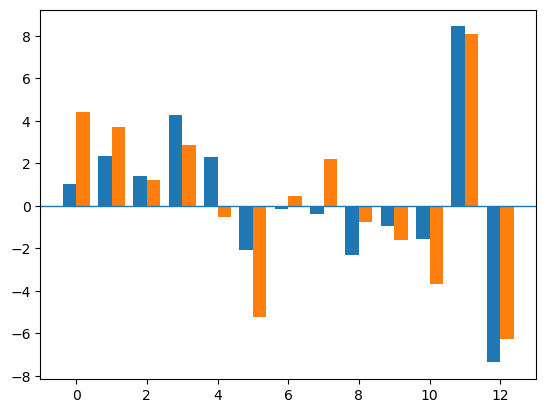

In [37]:
plt.figure()
x = np.arange(len(diag))
w = 0.38

plt.bar(x - w/2, diag["err_ns_bp"], width=w, label="NS error (bp)")
plt.bar(x + w/2, diag["err_nss_bp"], width=w, label="NSS error (bp)")
plt.axhline(0, linewidth=1)
plt.xticks(x, [f"{v:.3f}" for v in diag["tenor"]])
plt.title(f"Tenor-wise OOS errors on {pd.to_datetime(meta['test_date']).date()}")
plt.ylabel("Error = market - prediction (bp)")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# for the worst dates
worst_dates = df_oos.nsmallest(5, "gain_oos_bp")["Date"].tolist()

all_diag = []
for d in worst_dates:
    diag_i, meta_i = diagnose_oos_by_tenor(d, long, df_ns, df_nss)
    diag_i["Date"] = pd.to_datetime(d)
    all_diag.append(diag_i)

diag_worst = pd.concat(all_diag, ignore_index=True)

# gain < 0
diag_worst.groupby("tenor")["gain_by_tenor_bp"].agg(["mean","median","count"]).sort_values("mean")

,mean,median,count
tenor,,,
1.0,-2.100712,-1.611246,5
0.5,-0.819860,-2.278692,5
0.16666666666666666,-0.662672,-0.793643,5
30.0,-0.289290,-1.082269,5
0.3333333333333333,-0.242279,-0.867949,5
3.0,-0.203406,-1.569470,5
20.0,-0.160639,-0.277334,5
0.25,-0.154346,-0.318914,5
7.0,-0.016692,0.103133,5


In [33]:
diag2 = diag.copy()

diag2["bucket"] = pd.cut(
    diag2["tenor_years"],
    bins=[-np.inf, 1, 10, np.inf],
    labels=["short (<=1Y)", "belly (2Y-10Y)", "long (>10Y)"]
)

diag2.groupby("bucket")["gain_by_tenor_bp"].agg(["sum", "mean", "count"])

/var/folders/zt/lbh39vcn4ksbgkj7px6j4qxm0000gn/T/ipykernel_1523/3102410376.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diag2.groupby("bucket")["gain_by_tenor_bp"].agg(["sum", "mean", "count"])


,sum,mean,count
bucket,,,
short (<=1Y),-4.624672,-0.770779,6
belly (2Y-10Y),-3.351090,-0.670218,5
long (>10Y),1.422136,0.711068,2
